## Contratos da Prefeitura Municipal

## Páginas de interesse

Obtemos os dados de contratos da prefeitura de Caruaru acessando o Portal da Transparência. 


![contratos portal transparencia](../assets/cityhall_assets/contratos_prefeitura.png)

Somos levados à página de consulta. Não temos a opção de selecionarmos a data do contrato.

![formulário de pesquisa do portal](../assets/cityhall_assets/contratos_prefeitura_form.png)


Contudo, um pouco mais abaixo, temos informações sobre cada contrato e, notamos que existem, até a data desta documentação, 3379 registros.

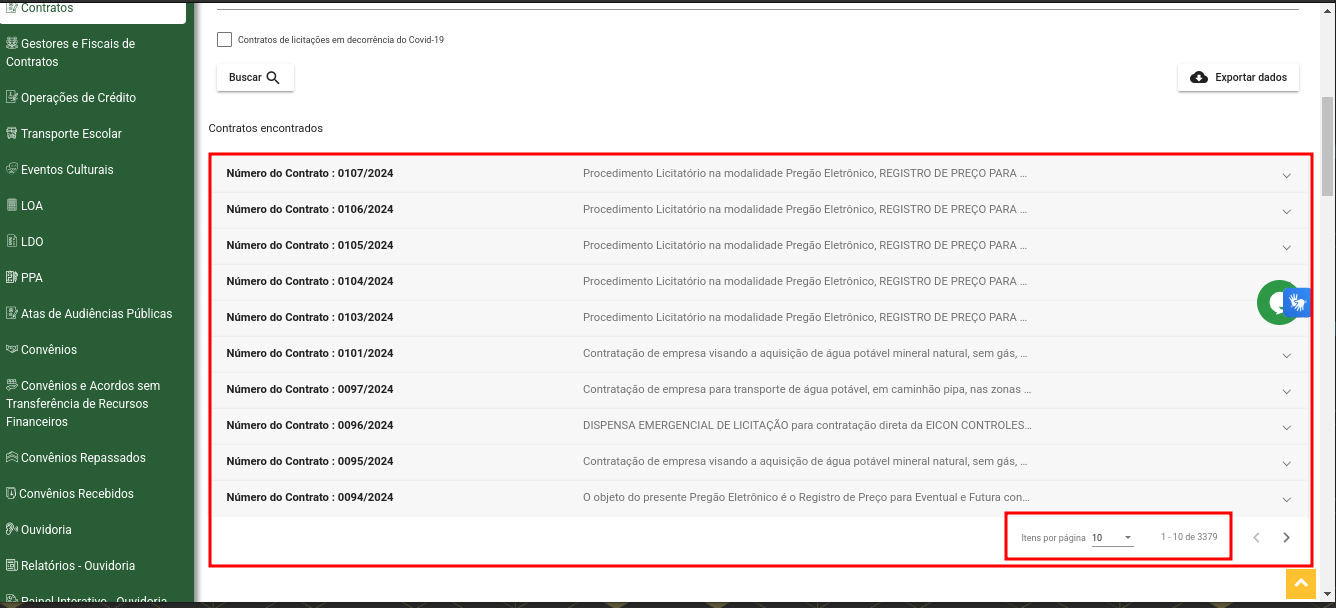

O botão "Exportar Dados" oferece diferentes opções de formatos de dados para download, porém baixa apenas a quantidade filtrada na caixa "Itens por página". 

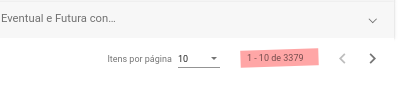

## Investigando a requisição de dados da página

Como o site carrega as informações programaticamanete, tomei a decisão de investigar a requisição que é realizada, quando selecionamos a opção JSON. Conforme a imagem abaixo, um novo arquivo é baixado e, nos Headers, uma solicitação foi feita para o seguinte endereço:

```
https://licitacoes.caruaru.pe.gov.br:8082/arquivo/contrato/exportar/json?&&&&&palavras_chave=&size=10&page=0
```



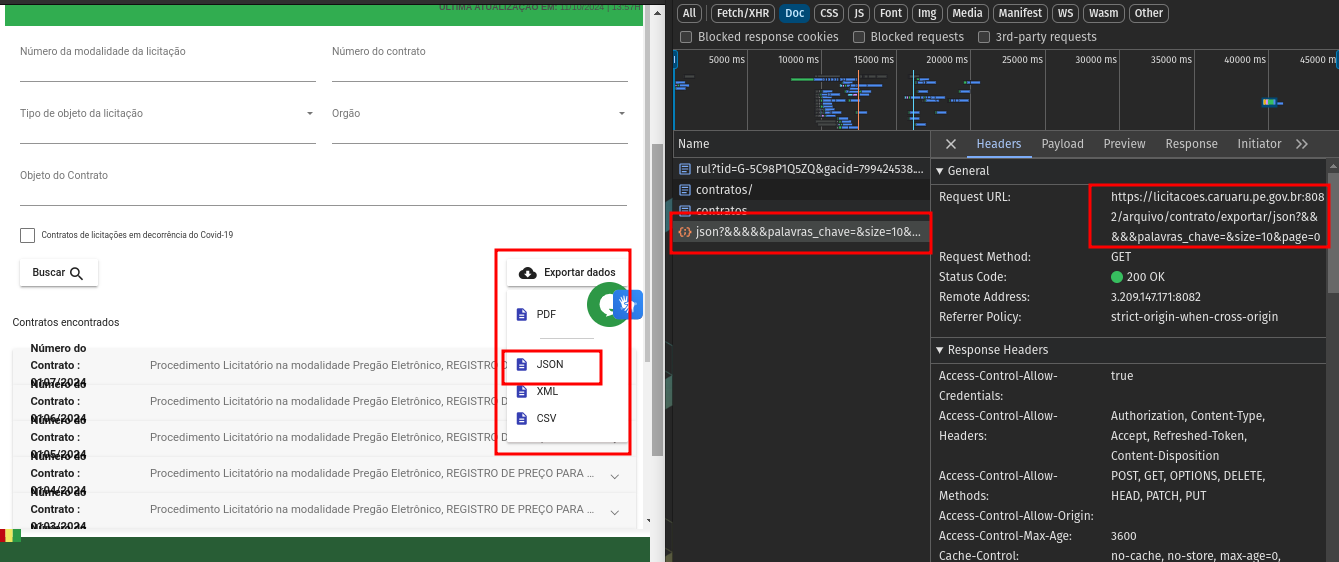

A parte após o símbolo de interrogação (?) na URL são os parâmetros de consulta. Esses parâmetros são usados para enviar informações adicionais ao servidor. Na url, temos:

- `?&&&&&`: Esta parte da URL não tem efeito prático. Ela representa múltiplos separadores `&`, mas pode ser removida sem impactar o funcionamento da URL.

`palavras_chave=`: Este é um parâmetro de consulta que, aparentemente, pode ser utilizado para filtrar os resultados com base em palavras-chave. Neste caso, está vazio, indicando que não foram fornecidas palavras-chave para a consulta.

`size=`: Parâmetro que especifica o tamanho do lote de registros a serem retornados. Em outras palavras, o valor indica quantos registros a API deve retornar por página.

`page=`: Parâmetro que indica o número da página a ser requisitada.


Os valores que nos interessam são os dois últimos, size e page. 

Ao realizar uma requisição obtemos os dados em formato json, o que permite trabalharmos diretamente com pandas, se quisermos.

In [4]:
import os
import json
import pandas as pd
import requests

contratos_url = 'https://licitacoes.caruaru.pe.gov.br:8082/arquivo/contrato/exportar/json?size=10&page=0'

response = requests.get(contratos_url)

data = response.json()

df = pd.DataFrame(data)

df.head()

,numero_contrato,licitacao_origem,objeto,tipo_objeto,orgao_gestor,valor_licitado,contratado,cpf_cnpj,data_publicacao,vigencia_inicio,vigenia_fim,documento_uri
0,0101/2024,090029/2024,Contratação de empresa visando a aquisição de ...,Compras e serviços,Secretaria de Administração,,MÁRCIO DO NASCIMENTO SILVA-ME,10875828000147,23/09/2024,23/09/2024,22/09/2025,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
1,0097/2024,090020/2024,Contratação de empresa para transporte de água...,Compras e serviços,Secretaria de Administração,,G O L NETO LTDA - ME,14949698000109,06/08/2024,06/08/2024,05/08/2025,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
2,0096/2024,0002/2024,DISPENSA EMERGENCIAL DE LICITAÇÃO para contrat...,Compras e serviços,Secretaria da Fazenda,"R$ 1.451.918,40",EICON CONTROLES INTELIGENTES DE NEGÓCIOS LTDA,53174058000118,19/07/2024,18/07/2024,18/07/2025,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
3,0103/2024,0039/2023,Procedimento Licitatório na modalidade Pregão ...,Compras e serviços,Secretaria de Administração,,SANIGRAN LTDA,15153524000190,27/09/2024,26/09/2024,25/09/2025,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
4,0104/2024,0039/2023,Procedimento Licitatório na modalidade Pregão ...,Compras e serviços,Secretaria de Administração,,SANTANA WERNECK COMERCIAL LTDA,11186469000183,27/09/2024,26/09/2024,25/09/2025,https://alfa-licitacoes.s3.sa-east-1.amazonaws...


## Obtendo todos os registros

In [5]:
df.count()

numero_contrato     10
licitacao_origem    10
objeto              10
tipo_objeto         10
orgao_gestor        10
valor_licitado      10
contratado          10
cpf_cnpj            10
data_publicacao     10
vigencia_inicio     10
vigenia_fim         10
documento_uri       10
dtype: int64

Como vemos acima, apenas 10 registros são retornados. Queremos os 3379 registros. Podemos tentar passar este valor para a variável size:  

In [7]:
contratos_url = 'https://licitacoes.caruaru.pe.gov.br:8082/arquivo/contrato/exportar/json?size=3379&page=0'

response = requests.get(contratos_url)

data = response.json()

df = pd.DataFrame(data)

df.shape

(2000, 12)

Curiosamente, o total de registros retornados é 2000. Isso pode estar relacionado com a capacidade de disponibilização de dados por página. Podemos verificar se incrementando a página temos algum retorno:

In [12]:
contratos_url = 'https://licitacoes.caruaru.pe.gov.br:8082/arquivo/contrato/exportar/json?size=2000&page=1'

response = requests.get(contratos_url)

data = response.json()

df = pd.DataFrame(data)

df.shape

(1379, 12)

Passando para página 1, obtemos 1379 registros. A soma dos dois resultados totaliza 3379. Isso significa que, para cada página, teremos que ralizar requisições com size = 2000 para obter os lotes de dados até atigirmos o limite de dados disponíveis. Como teremos que realizar este procedimento todas as vezes que precisarmos atualizar os dados, resolvi implementar uma função que checa a possibilidade de diferença entre os lotes. Se houver diferença, adiciono somente os dados inéditos ao arquivo csv final que, por enquanto, será criado localmente, um CDC (Change Data Capture) rústico. A função também conta a quantidade de requests realizados só para conhecimento.

In [21]:
# Função para buscar um lote de registros da API
def fetch_data(page, size):
    url = f'https://licitacoes.caruaru.pe.gov.br:8082/arquivo/contrato/exportar/json?size={size}&page={page}'
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Erro na requisição: {response.status_code}")
        return []

# Função para comparar os dois lotes e identificar as diferenças
def compare_batches(previous_batch, current_batch):
    # Converter os lotes em conjuntos de tuplas para facilitar a comparação
    prev_set = {tuple(item.items()) for item in previous_batch}
    curr_set = {tuple(item.items()) for item in current_batch}

    # Encontrar as diferenças (o que está no lote atual, mas não estava no anterior)
    differences = curr_set - prev_set

    # Converter de volta para o formato de lista de dicionários
    return [dict(item) for item in differences]

# Função para adicionar as diferenças ao DataFrame
def append_to_dataframe(differences, df):
    if not differences:
        return df

    # Criar um DataFrame com as diferenças
    new_df = pd.DataFrame(differences)
    
    # Verificar se o DataFrame já contém essas diferenças, evitando duplicatas
    df = pd.concat([df, new_df]).drop_duplicates().reset_index(drop=True)
    
    return df

# Função principal para raspar todas as páginas e comparar lotes
def scrape_all_pages():
    page = 0
    size = 2000  # Valor máximo de dados obtidos a cada requisição
    previous_batch = []
    requests_count = 0  # Contar a quantidade de requisições feitas
    
    # DataFrame vazio para armazenar os dados
    df = pd.DataFrame()

    while True:
        current_batch = fetch_data(page, size)

        requests_count += 1
        
        # Se não houver mais registros, pare o loop
        if not current_batch:
            break

        # Comparar o lote atual com o anterior
        differences = compare_batches(previous_batch, current_batch)

        # Se houver diferenças, adicionar ao DataFrame
        if differences:
            df = append_to_dataframe(differences, df)

        # O lote atual se torna o anterior para a próxima iteração
        previous_batch = current_batch

        # Avançar para a próxima página
        page += 1

    print(f'Quantidade de requisições realizadas: {requests_count}')
    return df

# Executar a função principal e obter o DataFrame final
df_final = scrape_all_pages()

Quantidade de requisições realizadas: 3


In [22]:
df_final.head()

,numero_contrato,licitacao_origem,objeto,tipo_objeto,orgao_gestor,valor_licitado,contratado,cpf_cnpj,data_publicacao,vigencia_inicio,vigenia_fim,documento_uri
0,0061/2023,0084/2022,Registro de preços para eventual e futuro forn...,Compras e serviços,Secretaria de Educação,,Eficiente Comércio e Serviços Eireli,28325460000109,01/09/2023,01/09/2023,30/08/2024,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
1,0163/2022,0003/2022,"O CREDENCIAMENTO DECLÍNICAS VETERINÁRIAS, HOSP...",Compras e serviços,Secretaria de Administração,,J.J. DE SOUZA RIBEIRO,14671782000103,,02/02/2023,02/02/2024,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
2,0057/2023,0084/2022,Registro de preços para eventual e futuro forn...,Compras e serviços,Secretaria de Educação,,Delta Indústria e Comércio Ltda,17602864000186,04/09/2023,04/09/2023,03/09/2024,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
3,0061/2023,0084/2023,Registro de preços para eventual e futura aqui...,Compras e serviços,Secretaria de Educação,,Eficiente Comércio e Serviços Eireli,28325460000109,01/09/2023,01/09/2023,30/08/2024,https://alfa-licitacoes.s3.sa-east-1.amazonaws...
4,0008/2024,0002/2024,Celebração de parceria com a Prefeitura Munici...,Compras e serviços,Secretaria de Desenvolvimento Social e Direito...,"R$ 120.000,00",ASSOCIACAO DE PESSOAS COM DEFICIENCIA DE CARUA...,01206707000111,18/06/2024,17/06/2024,16/06/2025,https://alfa-licitacoes.s3.sa-east-1.amazonaws...


In [23]:
df_final.shape

(3379, 12)

Com isso, temos a lógica para obtermos todos os dados disponíveis sobre os contratos da prefeitura municipal.